## Welcome to BoneCoT: An Advanced AI Model for Bone Disease Diagnosis

This notebook demonstrates BoneCoT - an advanced AI diagnostic system for bone tumors. BoneCoT builds upon BoneFM, a vision transformer backbone pre-trained on whole-body CT scans using DINOv2's self-supervised learning framework. By modeling the inherent relationships between diagnostic tasks, BoneCoT implements a Chain-of-Thought inference mechanism that enhances diagnostic capabilities by following clinical reasoning patterns.

### 1. BoneCoT Inference Configuration
- We provide a sample image in `data/eval_demo_data/imgs` that shows an **osteolytic** **BM** on left femur with **pathological fracture**. This image will be used to demonstrate BoneCoT's diagnostic capabilities.
- The configuration below sets up the inference pipeline for BoneCoT, including model loading, data preprocessing, and output handling.


In [1]:
import os
import argparse
from omegaconf import OmegaConf
import pathlib

# Create ArgumentParser object
parser = argparse.ArgumentParser(description="DinoV2 finetune")

# Add command line arguments
parser.add_argument("--config-file", type=str, default="finetune/configs/bonecot_eval.yaml", help="Model configuration file")
parser.add_argument("--output-dir", default="finetune_logs/bonecot_inference", type=str, help="Output directory to write results and logs")
parser.add_argument("--log-interval", type=int, help="Log interval", default=10)
parser.add_argument("--log_display", action="store_true", help="Whether to display log", default=True)

# Parse command line arguments, pass empty list to avoid reading from command line
args = parser.parse_args([])

# Load default config file and user specified config file
default_config_path = pathlib.Path("finetune/configs/default_configs.yaml")
default_cfg = OmegaConf.load(default_config_path)

# Load user config file
user_cfg = OmegaConf.load(args.config_file)

# Merge config files
merged_cfg = OmegaConf.merge(default_cfg, user_cfg)

# Apply merged config to args
for key, value in merged_cfg.items():
    if not hasattr(args, key):
        setattr(args, key, value)
    else:
        if getattr(args, key) is None:
            setattr(args, key, value)

# Update output_dir to absolute path
args.output_dir = os.path.abspath(args.output_dir)

# Create output directory if it doesn't exist
if not os.path.exists(args.output_dir):
    os.makedirs(args.output_dir)

# Set model checkpoint paths for each task relative to primary versus metastatic task in BoneCoT
# Each path points to a pretrained ViT-g/14 model for a specific diagnostic task
args.model.cot_relative_model_dict['bone_lesion'] = 'finetune/models/checkpoints/bone_lesion.pth'
args.model.cot_relative_model_dict['benign_malignant'] = 'finetune/models/checkpoints/benign_malignant.pth'
args.model.cot_relative_model_dict['primary_metastatic'] = 'finetune/models/checkpoints/primary_metastatic.pth'
args.model.cot_relative_model_dict['osteoblastic'] = 'finetune/models/checkpoints/osteoblastic.pth'
args.model.cot_relative_model_dict['osteolytic'] = 'finetune/models/checkpoints/osteolytic.pth'
args.model.cot_relative_model_dict['spinal_cord_compression'] = 'finetune/models/checkpoints/spinal_cord_compression.pth'
args.model.cot_relative_model_dict['thrombosis'] = 'finetune/models/checkpoints/thrombosis.pth'
args.model.cot_relative_model_dict['pathological_fracture'] = 'finetune/models/checkpoints/pathological_fracture.pth'
args.model.cot_relative_model_dict['type_of_primary_tumor'] = 'finetune/models/checkpoints/type_of_primary_tumor.pth'

# BoneCoT inference rounds
args.optim.epochs = 3

# Write final args to config.yaml file
args_dict = vars(args)
sorted_args_dict = dict(sorted(args_dict.items()))

config_yaml_path = os.path.join(args.output_dir, "config.yaml")
with open(config_yaml_path, "w") as f:
    OmegaConf.save(config=OmegaConf.create(sorted_args_dict), f=f)

print('Successfully loaded config file')

Successfully loaded config file


### 2. Run BoneCoT Inference

In this part, we will:
1. Initialize the BoneCoT evaluation trainer
2. Run inference using multiple ViT-g/14 models


In [2]:
# Note: BoneCoT requires multiple ViT-g/14 models working together for inference
# Minimum requirements: 128GB RAM and 8GB GPU VRAM for demo case
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

from finetune.trainer import BoneCoT_Eval_Trainer
# initialize trainer
bonecot_eval_trainer = BoneCoT_Eval_Trainer(args)
# run trainer
bonecot_eval_trainer.run()

/data/dataserver01/zhangruipeng/code/BoneFM/release/finetune/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/data/dataserver01/zhangruipeng/code/BoneFM/release/finetune/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/data/dataserver01/zhangruipeng/code/BoneFM/release/finetune/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
2025-03-09 11:07 Test dataset: finetune/data/eval_demo_data/labels/eval.csv / Length: 1 / loader: 1
2025-03-09 11:07 Use CoT relative model for inference: dict_keys(['bone_lesion', 'benign_malignant', 'primary_metastatic', 'osteoblastic', 'osteolytic', 'spinal_cord_compression', 'thrombosis', 'pathological_fracture', 'type_of_primary_tumor'])
2025-03-09 11:07 Model bone lesion Finished
2025-03-09 11:07 Model benign malignant Finished
2025-03-09 11:07 Model p

### 3. Show Results

In this part, we will:
1. Display the input CT image
2. Show BoneCoT's inference results focusing on Primary versus metastatic task
3. Show predictions for related tasks that help inform the Primary versus metastatic classification


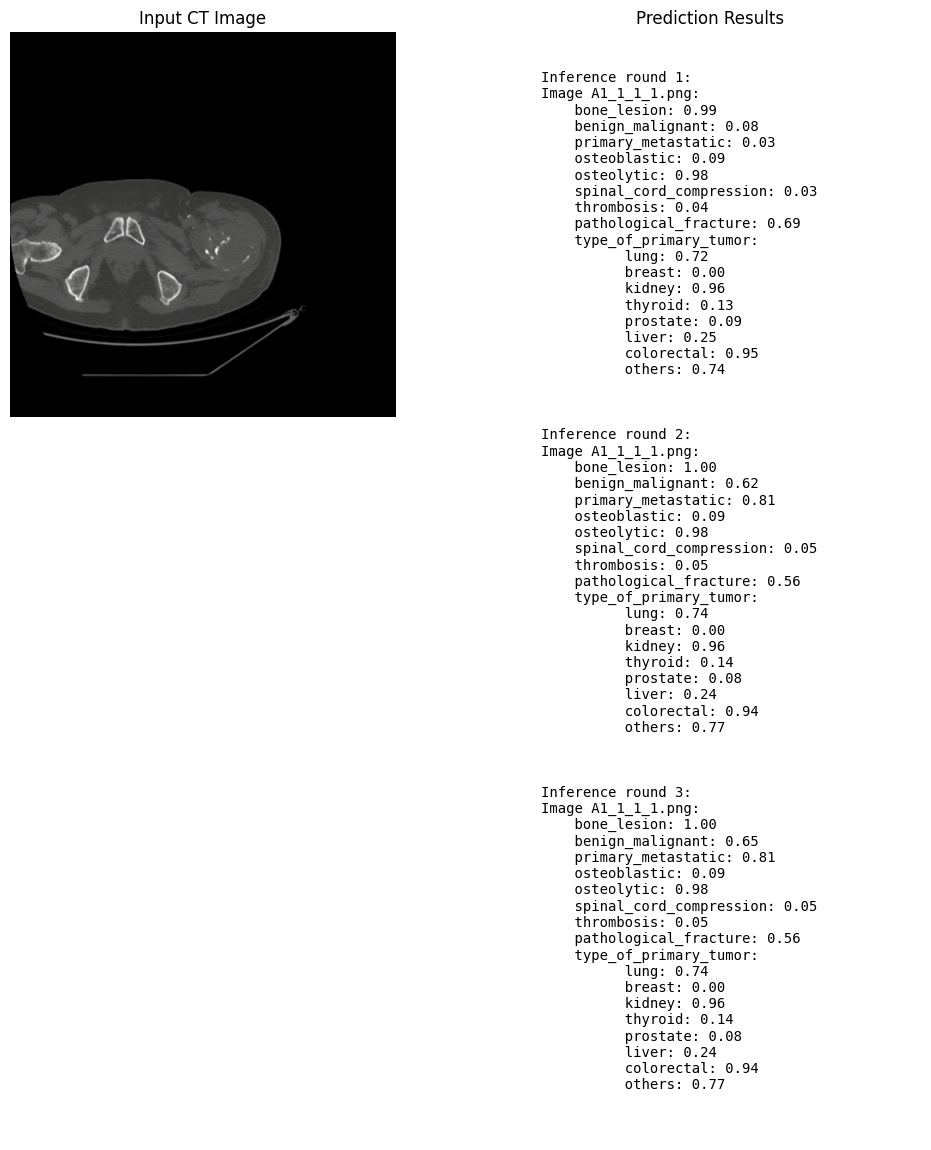

In [6]:
# show results
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# show the CT image
df = pd.read_csv(args.data.test_dataset)
img_list = df['img_path'].tolist()

# Get first image path
first_img_path = img_list[0]

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot - CT image
img = Image.open(first_img_path)
ax1.imshow(img, cmap='gray')
ax1.set_title('Input CT Image')
ax1.axis('off')

# Right subplot - Predictions
ax2.axis('off')
predictions_text = []

npz_list = [os.path.join(args.output_dir, "pred_npz", f) for f in os.listdir(os.path.join(args.output_dir, "pred_npz"))]
npz_list = sorted(npz_list)

# Read test dataset CSV file
test_df = pd.read_csv(args.data.test_dataset)


# get task name list
inference_task_list = []
for task_name in args.model.cot_relative_model_dict.keys():
    if os.path.exists(args.model.cot_relative_model_dict[task_name]):
        inference_task_list.append(task_name)

for n_round, npz_path in enumerate(npz_list):
    predictions_text.append(f"Inference round {n_round+1}:")
    data = np.load(npz_path, allow_pickle=True)
    data = data['arr_0']
    data = data.item()

    # Process each image in test dataset
    for _, row in test_df.iterrows():
        img_basename = os.path.basename(row['img_path'])
        keys = img_basename.split('_')  # Split filename to get hierarchy keys
        case_id, squence_id, slice_id, _ = keys
        
        predictions_text.append(f"Image {img_basename}:")
        
        # Process each task for this image
        for task_name in inference_task_list:
            if task_name not in data.keys():
                continue
                
            # Navigate through nested dict using keys
            result = data[task_name][case_id][squence_id]

            if result is not None:
                if task_name == 'type_of_primary_tumor':
                    outputs = result[img_basename]['outputs']
                    pred = torch.sigmoid(torch.tensor(outputs)).numpy()
                    tumor_list = ['lung', 'breast', 'kidney', 'thyroid', 'prostate', 'liver', 'colorectal', 'others']
                    pred_str = ""
                    for tumor_type, pred_value in zip(tumor_list, pred):
                        pred_str += " "*10 +f"{tumor_type}: {pred_value:.2f}\n"
                    predictions_text.append(f"    {task_name}:\n{pred_str}")
                else:
                    outputs = result[img_basename]['outputs'][0]
                    pred = torch.sigmoid(torch.tensor(outputs)).item()
                    predictions_text.append(f"    {task_name}: {pred:.2f}")
        predictions_text.append("\n")
# Display predictions in right subplot
ax2.text(0.1, 0.9, '\n'.join(predictions_text), 
         verticalalignment='top',
         fontsize=10,
         fontfamily='monospace')
ax2.set_title('Prediction Results')

plt.show()



### Analysis of BoneCoT inference results above
 
- In round 1, with only CT image input, BoneCoT detects bone lesions, osteolytic changes and pathological fractures.
- In round 2, incorporating both CT images and predictions from related tasks, BoneCoT successfully identifies bone metastasis (BM).
- In round 3, the predictions are further refined and adjusted based on the accumulated evidence from previous rounds.
